In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score
from sklearn.tree import plot_tree

print("Semua library berhasil di-import!")


Semua library berhasil di-import!


In [27]:
# Membaca file Excel pada lembar kerja kedua (indeks 1) yang berisi data asli
df = pd.read_excel('E_Commerce_Dataset.xlsx', sheet_name=1)

print(f"Dataset berhasil dimuat! Total data: {df.shape[0]} baris dan {df.shape[1]} kolom.")
print("\n--- Nama-Nama Kolom Asli yang Terdeteksi ---")
print(df.columns.tolist())

Dataset berhasil dimuat! Total data: 5630 baris dan 20 kolom.

--- Nama-Nama Kolom Asli yang Terdeteksi ---
['CustomerID', 'Churn', 'Tenure', 'PreferredLoginDevice', 'CityTier', 'WarehouseToHome', 'PreferredPaymentMode', 'Gender', 'HourSpendOnApp', 'NumberOfDeviceRegistered', 'PreferedOrderCat', 'SatisfactionScore', 'MaritalStatus', 'NumberOfAddress', 'Complain', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount']


/tmp/ipykernel_510/185359163.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=target_col, data=df, palette='Set2')


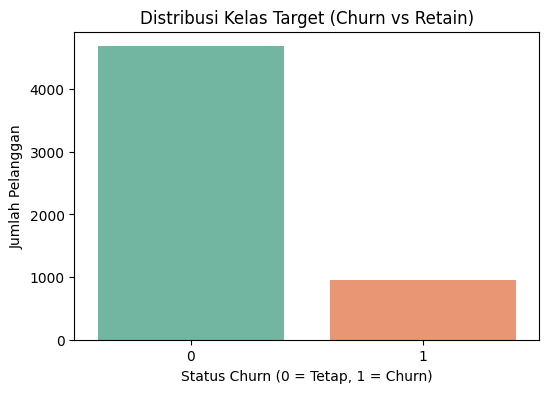

Jumlah kelas target:
Churn
0    4682
1     948
Name: count, dtype: int64
--------------------------------------------------
Jumlah Data Kosong Per Fitur:
CustomerID                       0
Churn                            0
Tenure                         264
PreferredLoginDevice             0
CityTier                         0
WarehouseToHome                251
PreferredPaymentMode             0
Gender                           0
HourSpendOnApp                 255
NumberOfDeviceRegistered         0
PreferedOrderCat                 0
SatisfactionScore                0
MaritalStatus                    0
NumberOfAddress                  0
Complain                         0
OrderAmountHikeFromlastYear    265
CouponUsed                     256
OrderCount                     258
DaySinceLastOrder              307
CashbackAmount                   0
dtype: int64


In [28]:
# Menentukan nama kolom target secara fleksibel (mengantisipasi huruf besar/kecil)
target_col = [col for col in df.columns if 'churn' in col.lower()]

if target_col:
    target_col = target_col[0] # Ambil nama kolom pertama yang cocok

    plt.figure(figsize=(6,4))
    sns.countplot(x=target_col, data=df, palette='Set2')
    plt.title('Distribusi Kelas Target (Churn vs Retain)')
    plt.xlabel('Status Churn (0 = Tetap, 1 = Churn)')
    plt.ylabel('Jumlah Pelanggan')
    plt.savefig('distribusi_churn.png', bbox_inches='tight')
    plt.show()

    print("Jumlah kelas target:")
    print(df[target_col].value_counts())
else:
    print("Peringatan: Kolom 'Churn' tidak ditemukan. Periksa kembali nama kolom di Sel 2.")

print("-" * 50)
print("Jumlah Data Kosong Per Fitur:")
print(df.isnull().sum())

In [29]:
# A. Pembersihan Data (Handling Null Values & Duplikat)
# Mengisi nilai kosong pada kolom numerik dengan nilai median
numeric_cols = df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

# Menghapus duplikat baris jika ada
df = df.drop_duplicates()

# Menghapus kolom ID jika terdeteksi (seperti CustomerID) agar tidak mengacaukan model
id_col = [col for col in df.columns if 'id' in col.lower()]
if id_col:
    df = df.drop(columns=id_col)
    print(f"Kolom identitas {id_col} berhasil dihapus.")

# B. Encoding Data Kategorik (Mengubah kolom teks menjadi angka)
label_encoders = {}
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

print("Data Preparation Selesai! Menampilkan 5 data teratas hasil transformasi:")
df.head()

Kolom identitas ['CustomerID'] berhasil dihapus.
Data Preparation Selesai! Menampilkan 5 data teratas hasil transformasi:


,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,1,4.0,1,3,6.0,4,0,3.0,3,2,2,2,9,1,11.0,1.0,1.0,5.0,159.93
1,1,9.0,2,1,8.0,6,1,3.0,4,3,3,2,7,1,15.0,0.0,1.0,0.0,120.90
2,1,9.0,2,1,30.0,4,1,2.0,4,3,3,2,6,1,14.0,0.0,1.0,3.0,120.28
3,1,0.0,2,3,15.0,4,1,2.0,4,2,5,2,8,0,23.0,0.0,1.0,3.0,134.07
4,1,0.0,2,1,12.0,0,1,3.0,3,3,5,2,3,0,11.0,1.0,1.0,3.0,129.60


In [30]:
# 1. Kita tunjuk langsung nama kolom target yang benar
target_col = 'Churn'

# Cek apakah kolom 'Churn' ada (mengantisipasi jika huruf kecil semua 'churn')
if target_col not in df.columns and 'churn' in df.columns:
    target_col = 'churn'

print(f"Mengunci target klasifikasi secara tepat pada kolom: '{target_col}'")
print("-" * 50)

# 2. Memisahkan Fitur (X) dan Target (y)
X = df.drop(columns=[target_col])
y = df[target_col]

# 3. Split Data (80% Train, 20% Test) dengan stratify agar seimbang
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. Normalisasi / Standarisasi Skala Data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Sukses! Ukuran Data Training (X_train): {X_train_scaled.shape}")
print(f"Sukses! Ukuran Data Testing (X_test): {X_test_scaled.shape}")

Mengunci target klasifikasi secara tepat pada kolom: 'Churn'
--------------------------------------------------
Sukses! Ukuran Data Training (X_train): (4504, 18)
Sukses! Ukuran Data Testing (X_test): (1126, 18)


In [31]:
# Algoritma 1: Decision Tree Classifier
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train_scaled, y_train)

# Algoritma 2: Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf_model.fit(X_train_scaled, y_train)

print("Proses pelatihan kedua model selesai tanpa eror!")

Proses pelatihan kedua model selesai tanpa eror!



 EVALUASI MODEL: DECISION TREE 
Confusion Matrix:
[[908  28]
 [ 93  97]]


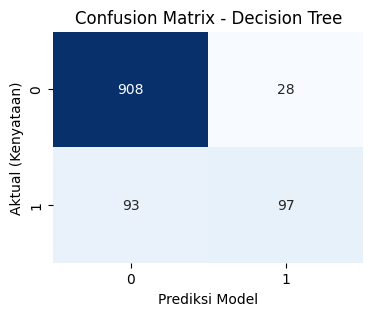


Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.97      0.94       936
           1       0.78      0.51      0.62       190

    accuracy                           0.89      1126
   macro avg       0.84      0.74      0.78      1126
weighted avg       0.88      0.89      0.88      1126


 EVALUASI MODEL: RANDOM FOREST 
Confusion Matrix:
[[925  11]
 [117  73]]


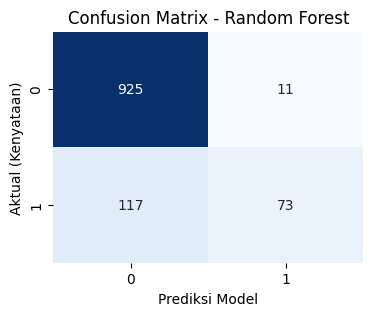


Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.99      0.94       936
           1       0.87      0.38      0.53       190

    accuracy                           0.89      1126
   macro avg       0.88      0.69      0.73      1126
weighted avg       0.88      0.89      0.87      1126



In [32]:
models = {'Decision Tree': dt_model, 'Random Forest': rf_model}

for name, model in models.items():
    # Melakukan prediksi pada data test
    y_pred = model.predict(X_test_scaled)

    print("\n" + "="*50)
    print(f" EVALUASI MODEL: {name.upper()} ")
    print("="*50)

    # 1. Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    print("Confusion Matrix:")
    print(cm)

    # Visualisasi Confusion Matrix Heatmap
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'Confusion Matrix - {name}')
    plt.ylabel('Aktual (Kenyataan)')
    plt.xlabel('Prediksi Model')
    plt.savefig(f'cm_{name.lower().replace(" ", "_")}.png', bbox_inches='tight')
    plt.show()

    # 2. Metrik Evaluasi Lengkap
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))